In [23]:
import os

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from scipy.spatial.distance import cdist, pdist, squareform

import torch
import lightning as L
from lightning.pytorch.callbacks import TQDMProgressBar

import logging
logger = logging.getLogger('tensorboard')
logger.setLevel(logging.WARNING)
# logger.propagate = False

import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

lembas = '/home/hmbaghda/Projects/LEMBAS'
sys.path.insert(1, os.path.join(lembas))
from LEMBAS.model.bionetwork import format_network, SignalingModel

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import parse_network, io
from scLEMBAS.plotting import plot_embedding
from scLEMBAS.preprocess import embed_tf_activity
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import SignalingDataModule, TimerCallback

In [24]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888

device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')
if not os.path.isdir(models_path):
    os.mkdir(models_path)

In [25]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))

# Load and Parse Input Signaling Network

In [26]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [27]:
sn_ppis = parse_network.load_network('omnipath', organism = 'mouse', static = True)
sn_ppis = parse_network.extract_network(sn_ppis, curation_effort_thresh = 5, n_references_thresh = 3,
                                        resources = ['HuRI','IntAct','KEGG-MEDICUS','NetPath','Reactome_SignaLink3','SPIKE','SignaLink3','SIGNOR', 
                                                'Baccin2019', 'Ramilowski2015', 'Reactome_LRdb', 'UniProt_LRdb', 'CellChatDB', 'CellPhoneDB', 'connectomeDB2020', 'scConnect'], 
                                        drop_self = True, verbose = True)

The thresholds filtered 21403  of 28277 interactions
The resources filtered 937  of 6874 interactions


Filter for nodes that fall in paths between ligands and receptors (fully connected network):

In [28]:
tf_labels = tf_adata.var.index.unique().tolist()

ligand_labels = tf_adata.obs['sample'].unique().tolist()
ligand_labels = [(l[0] + l[1:].lower()).replace('-', '') for l in ligand_labels] # mouse naming convention

# filter for paths b/w ligand and tf
fn_1 = parse_network.fully_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'shortest')
fn_2 = parse_network.fully_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'connected')
# of the methods to identify paths, retain the one that has the most interactions
if fn_1.shape[0] > fn_2.shape[0]:
    sn_ppis = fn_1
else:
    sn_ppis = fn_2

del fn_1, fn_2


100%|████████████████████████████████████| 8122/8122 [00:00<00:00, 17134.04it/s]


Finally, let's format the network as needed for input to building the model:

In [29]:
# for the interactions that are labeled as both stimulating and inhibiting, relabel them as unknown (can only have one direction)
sn_ppis.loc[sn_ppis[(sn_ppis[stimulation_label] == 1) & (sn_ppis[inhibition_label] == 1)].index, 
    [stimulation_label, inhibition_label]] = [False, False]
sn_ppis = parse_network.format_network(sn_ppis, weight_label, stimulation_label, inhibition_label) 

In [30]:
print('The signaling network contains {} interactions'.format(sn_ppis.shape[0]))
sn_ppis[[source_label, target_label, weight_label, stimulation_label, inhibition_label]].head()

The signaling network contains 619 interactions


,source_genesymbol,target_genesymbol,mode_of_action,consensus_stimulation,consensus_inhibition
0,Mapk14,Mapkapk2,1.0,True,False
1,Mapkapk2,Mapk14,0.1,False,False
2,Akt1,Chuk,1.0,True,False
3,Tp53,Atf3,1.0,True,False
4,Abl1,Tp73,1.0,True,False


The interactions include the following input ligands:

In [31]:
all_nodes = sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()
input_ligands_available = sorted(set(ligand_labels).intersection(all_nodes))
print(*input_ligands_available, sep = ', ')

Egf, Gdnf, Hgf, Ifng, Il10, Il11, Il13, Il15, Il1a, Il1b, Il2, Il21, Il4, Il5, Il6, Il7, Il9, Lif, Osm, Tslp


# Explore performance on TF activity

## Scenario 1:

In [32]:
model_no = 1

The simplest scenario is:
- 1 cell type
- 1 ligand
- Binary ligand exposure (0 or 1)
- Exposure leads to distinct clusters in TF activity space

To identify the two most distinct clusters, let's calculate the Euclidean distance of the cluster centroids in PC space:

In [33]:
group_label = 'TF_clusters' # ordered cateogry in obs

pca_rank = tf_adata.uns['pca']['pca_rank']
X_pca = tf_adata.obsm['X_pca'][:, :pca_rank] # PCA to pca_rank components

clf = NearestCentroid()
clf.fit(X_pca, np.array(tf_adata.obs[group_label]))
centroids = clf.centroids_ # group labels x n_pcs
ped = squareform(pdist(centroids, 'euclidean')) # euclidean distance between all centroids

max_clusters = np.unravel_index(np.argmax(ped), ped.shape)
max_clusters = [clf.classes_[i] for i in max_clusters]
print('Centroid euclidean distance in PC space is maximized between cluster {} and {} ({} PCs)'.format(*max_clusters, tf_adata.uns['pca']['pca_rank']))

ped_ = ped.copy()
np.fill_diagonal(ped_, np.inf)
min_clusters = np.unravel_index(np.argmin(ped_), ped_.shape)
min_clusters = [clf.classes_[i] for i in min_clusters]
print('Centroid euclidean distance in PC space is minimized between cluster {} and {} ({} PCs)'.format(*min_clusters, tf_adata.uns['pca']['pca_rank']))

Centroid euclidean distance in PC space is maximized between cluster 15 and 9 (8 PCs)
Centroid euclidean distance in PC space is minimized between cluster 6 and 9 (8 PCs)


Let's also get the within-cluster dispersion, as measured by WCSS. We adapt the below equation of WCSS to calculate just the inner sum for each cluster(not summing across all clusters, which gives one metric of overall dispersion) and normalize to the total number of points in the cluster:



$$
\text{WCSS} = \sum_{i=1}^{k} \sum_{\mathbf{x} \in C_i} [d(\mathbf{x}, \mathbf{\mu}_i)]^2
$$


- $k$: The number of clusters.
- $C_i$: The set of points belonging to the $i$-th cluster.
- $\mathbf{x}$: A data point within a cluster $C_i$.
- $\mathbf{\mu}_i$: The centroid of the $i$-th cluster, which is the average position of all the points in $C_i$.
- $d(\mathbf{x}, \mathbf{\mu}_i)$: The distance between a data point $\mathbf{x}$ and the centroid (here calculated as Euclidean distance)

Our WCSS:

For each $k$k:
$$
\text{WCSS} = \sum_{\mathbf{x} \in C_i} [d(\mathbf{x}, \mathbf{\mu}_i)]^2 / n
$$

- $n$: The total number of points in the cluster


In [34]:
WCSS = {}
cluster_map = tf_adata.obs[['TF_clusters']].reset_index(drop = True)
for i, centroid in enumerate(centroids):
    cluster_label = clf.classes_[i]
    cluster_indeces = cluster_map[cluster_map.TF_clusters == cluster_label].index.tolist()
    cluster_points = X_pca[cluster_indeces,:]

    # squared_distances = np.sum((cluster_points - centroid) ** 2, axis=1)
    euclidean_distance = cdist(cluster_points, [centroid], 'euclidean')
    squared_distances = np.sum(euclidean_distance**2, axis = 1)

    WCSS[cluster_label] = np.sum(euclidean_distance**2)/cluster_points.shape[0]

WCSS = pd.DataFrame(WCSS.items(), columns = ['TF_cluster', 'WCSS'])
WCSS.sort_values(by = 'WCSS', ascending = True, inplace = True)
WCSS.reset_index(drop = True, inplace = True)

max_cluster, min_cluster = WCSS.loc[WCSS.WCSS.idxmax(), 'TF_cluster'], WCSS.loc[WCSS.WCSS.idxmin(),  'TF_cluster']
print('Cluster {} has the max dispersion in PC space'.format(max_cluster))
print('Cluster {} has the min dispersion in PC space'.format(min_cluster))

Cluster 8 has the max dispersion in PC space
Cluster 9 has the min dispersion in PC space


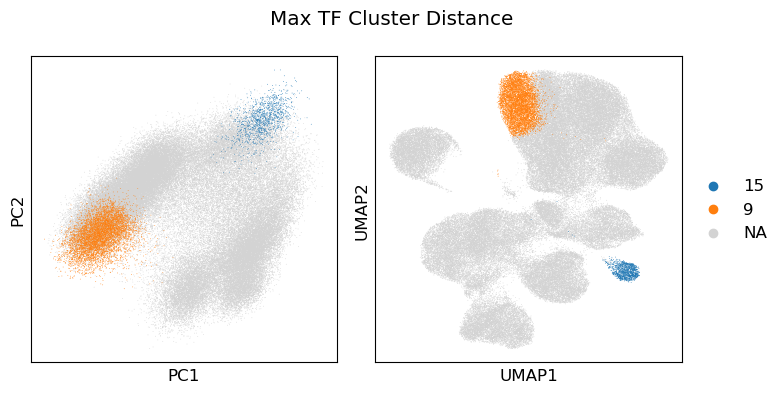

In [35]:
viz_adata = tf_adata.copy()
viz_adata.obs[group_label + '_color'] = pd.Categorical(viz_adata.obs[group_label], 
                                                       categories = max_clusters, 
                                                       ordered = True)
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(viz_adata, color=group_label + '_color', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(viz_adata, color=group_label + '_color', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('Max TF Cluster Distance')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

Based on these results, let's say that cluster 9 is unstimulated, and cluster 15 is stimulated. 

In [36]:
np.random.seed(seed)
selected_ligand = np.random.choice(input_ligands_available, 1)[0]
print('The selected ligand is: ' + selected_ligand)

subset_tf = tf_adata[tf_adata.obs.TF_clusters.isin(['9', '15'])]
subset_tf.obs.TF_clusters.value_counts()

The selected ligand is: Il5


TF_clusters
9     6153
15    1168
Name: count, dtype: int64

To avoid any bias, let's randomly subset the larger cluster to match the size of the smaller one:

In [37]:
sample_size = subset_tf.obs.TF_clusters.value_counts().min()
large_cluster = subset_tf.obs.TF_clusters.value_counts().idxmax()
small_cluster = subset_tf.obs.TF_clusters.value_counts().idxmin()
large_cluster_barcodes = subset_tf.obs[subset_tf.obs.TF_clusters == large_cluster].index
small_cluster_barcodes = subset_tf.obs[subset_tf.obs.TF_clusters == small_cluster].index.tolist()
np.random.seed(seed)
lcb_sub = list(np.random.choice(large_cluster_barcodes, sample_size, replace = False))
subset_tf = subset_tf[lcb_sub + small_cluster_barcodes, :]
subset_tf.obs.TF_clusters.value_counts()

TF_clusters
9     1168
15    1168
Name: count, dtype: int64

For now, for speed, let's subset so that there are just 100 "samples" per stimulation condition:

In [38]:
# sample_size = 100

# barcodes = []
# for cluster_label in subset_tf.obs.TF_clusters.unique():
#     bc = subset_tf.obs[subset_tf.obs.TF_clusters == cluster_label].index
#     np.random.seed(seed)
#     barcodes += list(np.random.choice(bc, sample_size, replace = False))
# subset_tf = subset_tf[barcodes, :]
# subset_tf.obs.TF_clusters.value_counts()

Next, let's initialize the model:

In [39]:
ligand_input = pd.DataFrame(subset_tf.obs.TF_clusters.map({'9': 0, '15': 1}))
ligand_input.columns = [selected_ligand]
tf_output = pd.DataFrame(subset_tf.X, index = subset_tf.obs.index, columns = subset_tf.var.index)

# Test

In [1]:
import os

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from scipy.spatial.distance import cdist, pdist, squareform

import torch
import lightning as L
from lightning.pytorch.callbacks import TQDMProgressBar

import logging
logger = logging.getLogger('tensorboard')
logger.setLevel(logging.WARNING)
# logger.propagate = False

import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

lembas = '/home/hmbaghda/Projects/LEMBAS'
sys.path.insert(1, os.path.join(lembas))
from LEMBAS.model.bionetwork import format_network, SignalingModel

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import parse_network, io
from scLEMBAS.plotting import plot_embedding
from scLEMBAS.preprocess import embed_tf_activity
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import SignalingDataModule, TimerCallback



n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888

device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')
if not os.path.isdir(models_path):
    os.mkdir(models_path)


source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'
# temp_inputs = {'sn_ppis': sn_ppis, 'ligand_input': ligand_input, 'tf_output': tf_output}
# from scLEMBAS.io import write_pickled_object
# write_pickled_object(temp_inputs, 'trash.pickle')
from scLEMBAS.io import read_pickled_object
temp_inputs = read_pickled_object('trash.pickle')
sn_ppis = temp_inputs['sn_ppis']
ligand_input = temp_inputs['ligand_input']
tf_output = temp_inputs['tf_output']

<Figure size 100x100 with 0 Axes>

In [4]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 'max_steps': 120, 'exp_factor':50, 'tolerance': 1e-5, 'leak':1e-2} # fed directly to model

# training parameters
base_training_params = {'optimizer': torch.optim.Adam, 'loss_fn': torch.nn.MSELoss(reduction='mean'), 
                        'max_epochs': 5000, 'peak_height': 1000, 'end_height': 1e-6}
lr_params = { 'learning_rate': 2e-3, 'reset_optimizer_epoch': 200}
other_params = {'network_noise_scale': 10, 'gradient_noise_level': 1e-9}
regularization_params = {'param_lambda_L2': 1e-6, 'moa_lambda_L1': 0.1, 'ligand_lambda_L2': 1e-5, 'uniform_lambda_L2': 1e-4, 
                   'uniform_max': (1/1.2), 'spectral_loss_factor': 1e-5}
spectral_radius_params = {'n_probes_spectral': 5, 'power_steps_spectral': 50, 'subset_n_spectral': 10}
training_params = {**base_training_params, **lr_params, **other_params, **regularization_params, **spectral_radius_params}
target_spectral_radius = 0.8
batch_size = 256

In [5]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     activation_function = 'MML', 
                     skip_bionet_out = False,
                     covariates = None,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                    device = device, dtype = torch.float32, seed = seed)
mod.to(torch.float32)
mod.to(device)

SignalingModel(
  (input_layer): ProjectInput()
  (signaling_network): BioNet()
  (output_layer): ProjectOutput()
)

In [6]:
model_no = 0

In [7]:
### training

# setup
mod.configure_training(training_params)
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

sdm = SignalingDataModule(X_in = mod.df_to_tensor(mod.X_in), 
                         y_out = mod.df_to_tensor(mod.y_out), 
                         batch_size = batch_size, 
                         train_split_frac = {'train': 0.8, 'validation': 0.2})
sdm.setup()
# io.write_pickled_object(sdm, os.path.join(models_path, 'model_' + str(model_no) + '_datamodule.pickle'))

# run
trainer = L.Trainer(
    callbacks=[TimerCallback(), TQDMProgressBar(refresh_rate = 500)],
    max_epochs=mod.training_params['max_epochs'],
    max_steps = -1,
    accelerator = device, 
    devices = 'auto',
    logger = True,
    # fast_dev_run = True,
    # overfit_batches = 10,
    accumulate_grad_batches = 1,
)
trainer.fit(model = mod, datamodule = sdm)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                 | Type                    | Params
-----------------------------------------------------------------
0 | input_layer          | ProjectInput            | 1     
1 | signaling_network    | BioNet                  | 110 K 
2 | output_layer         | ProjectOutput           | 193   
3 | loss_fn              | MSELoss                 | 0     
4 | train_recon_sigma    | StandardDeviationMetric | 0     
5 | train_spectral_sigma | StandardDeviationMetric | 0     
-------------------------------------

Epoch 0: 100%|█| 8/8 [00:01<00:00,  6.95it/s, v_num=38, reconstruction_loss=1.26e=0, l=1.26003, s=0.86230, r=0.00020, v=0.00000
Epoch 576:   0%| | 0/8 [00:00<?, ?it/s, v_num=38, reconstruction_loss=0.624, spe

In [ ]:
mod.

In [6]:
from scLEMBAS.model.model_utilities import get_lr
from scLEMBAS import utilities as utils
# mod.load_state_dict(torch.load(os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth')))
self = mod
# self.trainer = trainer

In [7]:
# epoch start
self.current_lr = get_lr(self.current_epoch, self.training_params['max_epochs'], max_height = self.training_params['learning_rate'], start_height=self.training_params['learning_rate']/10, end_height=1e-6, peak = 1000)
self.optimizers().param_groups[0]['lr'] = self.current_lr

tensor(True)

In [8]:
# step start
counter = 0
for batch, (X_in_, y_out_) in enumerate(sdm.train_dataloader()):
    if counter > 0:
        break
        
    optimizer = self.optimizers()
    optimizer.zero_grad() # because self.automatic_optimization=False    
    X_in_, y_out_ = X_in_.to(device), y_out_.to(device)
    
    counter += 1
self.to(device)

SignalingModel(
  (input_layer): ProjectInput()
  (signaling_network): BioNet()
  (output_layer): ProjectOutput()
  (loss_fn): MSELoss()
  (train_recon_sigma): StandardDeviationMetric()
  (train_spectral_sigma): StandardDeviationMetric()
)

In [19]:
X_in = X_in_
X_full = torch.zeros([X_in.shape[0],  self.input_layer.size_out], dtype=self.input_layer.dtype, device=self.input_layer.device) # shape of (samples x total nodes in network)


In [21]:
torch.isnan(X_full).any()

tensor(False, device='cuda:0')

In [ ]:
X_full[:, self.input_node_order] = self.weights * X_in 

In [29]:
torch.isnan(self.input_layer.weights * X_in).any()

tensor(True, device='cuda:0')

In [30]:
self.input_layer.weights

Parameter containing:
tensor([nan], device='cuda:0', requires_grad=True)

In [9]:
# X_full = self.input_layer(X_in_.to(self._device))


In [17]:
torch.isnan(self.input_layer(X_in_.to(self._device))).any()

tensor(True, device='cuda:0')

In [18]:
torch.isnan(X_in_).any()

tensor(False)

In [ ]:
utils.set_seeds(self.seed + self._gradient_seed_counter)
network_noise = torch.randn(X_full.shape, device = X_full.device)
X_full = X_full + (self.training_params['network_noise_scale'] * self.current_lr * network_noise) 
# Y_full = self.signaling_network(X_full)


In [152]:
self.signaling_network.weights.data.masked_fill_(mask = self.signaling_network.mask, value = 0.0) # fill non-interacting edges with 0

X_bias = X_full.T + self.signaling_network.bias # this is the bias with the projection_amplitude included
X_new = torch.zeros_like(X_bias) #initialize all values at 0


X_old = X_new
X_new = torch.mm(self.signaling_network.weights, X_new) # scale matrix by edge weights
X_new = X_new + X_bias  # add original values and bias       
X_new = self.signaling_network.activation(X_new, self.signaling_network.training_params['leak'])

In [155]:
torch.isnan(X_new).any()

tensor(False, device='cuda:0')

In [156]:
for t in range(self.signaling_network.training_params['max_steps']): # like an RNN, updating from previous time step
    X_old = X_new
    X_new = torch.mm(self.signaling_network.weights, X_new) # scale matrix by edge weights
    X_new = X_new + X_bias  # add original values and bias       
    X_new = self.signaling_network.activation(X_new, self.signaling_network.training_params['leak'])
    if torch.isnan(X_new).any().item():
        print(t)
        break

    if (t % 10 == 0) and (t > 20):
        diff = torch.max(torch.abs(X_new - X_old))    
        if diff.lt(self.signaling_network.training_params['tolerance']):
            break

Y_full = X_new.T

In [157]:
torch.isnan(Y_full).any().item()

False

In [ ]:
X_new = X_new + X_bias  # add original values and bias       
X_new = self.signaling_network.activation(X_new, self.signaling_network.training_params['leak'])

In [131]:
X_bias = X_full.T + self.signaling_network.bias # this is the bias with the projection_amplitude included


False

0


In [113]:
X_old = X_new
X_new = torch.mm(self.signaling_network.weights, X_new) # scale matrix by edge weights


In [117]:
torch.isnan(X_bias).any().item()

True

In [115]:
X_new = X_new + X_bias  # add original values and bias       


In [ ]:
X_new = self.signaling_network.activation(X_new, self.signaling_network.training_params['leak'])

In [92]:
X_old = X_new
X_new = torch.mm(self.signaling_network.weights, X_new)
X_new = X_new + X_bias
X_new = self.signaling_network.activation(X_new, self.signaling_network.training_params['leak'])

False

In [ ]:
X_full = torch.zeros([X_in.shape[0],  self.size_out], dtype=self.dtype, device=self.device) # shape of (samples x total nodes in network)
X_full[:, self.input_node_order] = self.weights * X_in

In [ ]:
X_full = torch.zeros([X_in.shape[0],  self.size_out], dtype=self.dtype, device=self.device)

In [ ]:
Y_hat = self.output_layer(Y_full)

In [64]:
reconstruction_loss = self.loss_fn(y_out_, Y_hat)

# get regularization losses
sign_reg = self.signaling_network.sign_regularization(lambda_L1 = self.training_params['moa_lambda_L1']) # incorrect MoA
ligand_reg = self.ligand_regularization(lambda_L2 = self.training_params['ligand_lambda_L2']) # ligand biases
stability_loss, spectral_radius = self.signaling_network.get_SS_loss(Y_full = Y_full.detach(), spectral_loss_factor = self.training_params['spectral_loss_factor'],
                                                                    subset_n = self.training_params['subset_n_spectral'], n_probes = self.training_params['n_probes_spectral'], 
                                                                    power_steps = self.training_params['power_steps_spectral'])
uniform_reg = self.uniform_regularization(lambda_L2 = self.training_params['uniform_lambda_L2']*self.current_lr, Y_full = Y_full, 
                                         target_min = 0, target_max = self.training_params['uniform_max']) # uniform distribution
param_reg = self.L2_reg(self.training_params['param_lambda_L2']) # all model weights and signaling network biases

total_loss = reconstruction_loss + sign_reg + ligand_reg + param_reg + stability_loss + uniform_reg

In [68]:
X_full

tensor([[ 0.0193, -0.0057, -0.0036,  ...,  0.0125, -0.0130,  0.0011],
        [-0.0050,  0.0137, -0.0085,  ..., -0.0031, -0.0100, -0.0157],
        [ 0.0047, -0.0246,  0.0052,  ..., -0.0091, -0.0069, -0.0032],
        ...,
        [ 0.0005, -0.0003, -0.0029,  ...,  0.0026, -0.0059,  0.0162],
        [-0.0039, -0.0234,  0.0087,  ..., -0.0043,  0.0088,  0.0187],
        [ 0.0109,  0.0372, -0.0153,  ...,  0.0039,  0.0119,  0.0114]],
       device='cuda:0', grad_fn=<AddBackward0>)

In [45]:
if self.current_epoch > 400 and np.isnan(self.trainer.callback_metrics["reconstruction_loss"].item()):
if torch.isnan(self.input_layer.weights).any():
    print(self.current_epoch)
    self.trainer.should_stop = True

tensor([120])

# you are here

Next, let's train the model:

In [22]:
mod.load_state_dict(torch.load(os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth')))
sdm = io.read_pickled_object(os.path.join(models_path, 'model_' + str(model_no) + '_datamodule.pickle'))

Let's see what the output looks like:

In [23]:
def unique_tol(arr, tol=1e-5, axis=0):
    if axis == 1:
        arr = arr.T
    norm_arr = arr / arr[:, [0]]
    
    # Sort the array based on rows
    sorted_indices = np.lexsort(norm_arr.T)
    sorted_arr = arr[sorted_indices, :]
    
    # Calculate the differences between consecutive rows
    diffs = np.diff(sorted_arr, axis=0)
    
    # Use a norm (e.g., L2 norm) to find row differences, then check against tolerance
    row_diffs = np.linalg.norm(diffs, axis=1)
    unique_row_indices = np.where(row_diffs > tol)[0]
    
    # Add the first row and the rows after significant changes
    unique_indices = np.r_[0, unique_row_indices + 1]
    
    # Select the unique rows
    unique_rows = sorted_arr[unique_indices, :]
    
    if axis == 1:
        unique_rows = unique_rows.T
        
    return unique_rows

In [26]:
y_pred, Y_full = mod(mod.df_to_tensor(X_test))
y_pred = y_pred.cpu().detach().numpy()

y_pred_unique = unique_tol(y_pred, tol = 1e-5, axis = 0)
print('The number of unique predictions across all test data is {}'.format(len(y_pred_unique)))

The number of unique predictions across all test data is 2


We can see that there are only 2 unique prediction values, because the model is currently not aware of single-cell resolution (or cell type) data. Let's see what exactly these predicted values are:

In [155]:
ligand_input[selected_ligand] = pd.Categorical(ligand_input[selected_ligand], 
                                              categories = sorted(ligand_input[selected_ligand].unique()), 
                                              ordered = True)

# get the centroids in the full TF activity space
clf_full = NearestCentroid()
clf_full.fit(y_train, ligand_input.loc[y_train.index, selected_ligand])
train_centroids = pd.DataFrame(clf_full.centroids_ , index = clf_full.classes_, columns = y_train.columns)

# get the predictions for stimulated (1) and unstimulated (0)
y_pred_1, _ = mod(mod.df_to_tensor(pd.DataFrame(X_test[X_test[selected_ligand] == 1].iloc[0, :]).T))
y_pred_1 = y_pred_1.cpu().detach().numpy()
y_pred_0, _ = mod(mod.df_to_tensor(pd.DataFrame(X_test[X_test[selected_ligand] == 0].iloc[0, :]).T))
y_pred_0 = y_pred_0.cpu().detach().numpy()

# re-run the PCA on the training subset to visualize/project into this space
tf_adata_train = tf_adata[y_train.index, y_train.columns].copy()
tf_adata_train.obs.drop(columns = ['TF_clusters'], inplace = True)
tf_adata_train = embed_tf_activity(tf_adata_train, estimate_key = None, scanpy_pca = False)
tf_adata_train.TF_clusters = tf_adata[y_train.index, y_train.columns].obs.TF_clusters # replace with original clusters
pca = tf_adata_train.uns['pca']['pca_mod']

# get the train dataset centroids as well as project the predictions into pca space 
train_pca_centroids = pca.transform(train_centroids)
pred_pca_centroids = pca.transform(np.concatenate((y_pred_0, y_pred_1)))

# sanity check
clf_reduced = NearestCentroid()
clf_reduced.fit(tf_adata_train.obsm['X_pca'], ligand_input.loc[tf_adata_train.obs.index, selected_ligand])
reduced_centroids = pd.DataFrame(clf_reduced.centroids_ , index = clf_reduced.classes_)
if not np.allclose(reduced_centroids, pca_centroids):
    print('Something went wrong')

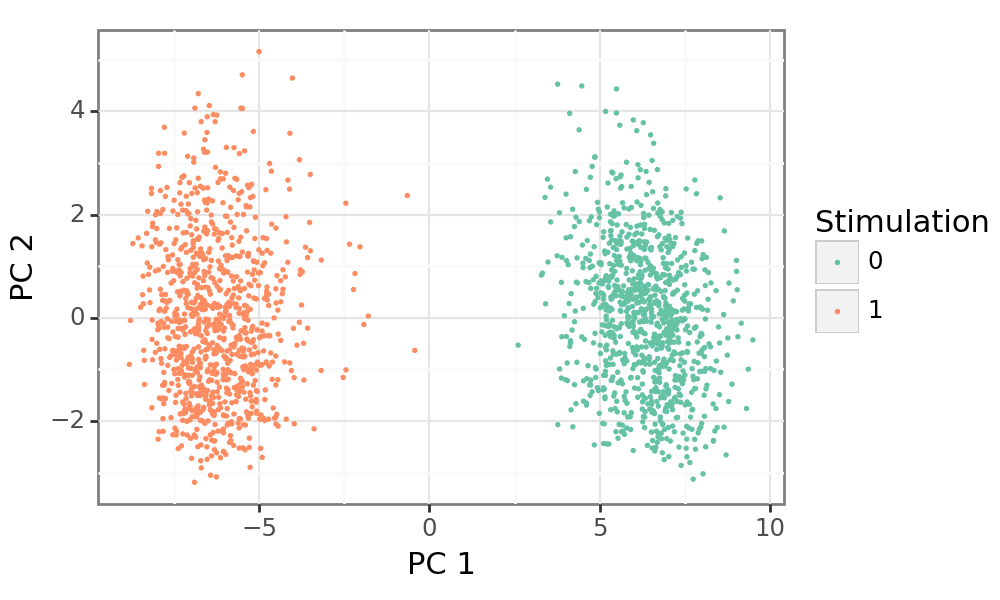

<Figure Size: (500 x 300)>

In [201]:
width, height = 5,3
p1 = plot_embedding(adata = tf_adata_train, group_label = 'Stimulation', embedding = 'pca', 
                    palette = 'Set2', width = 3, height = 3, size = 0.1)
p1 + p9.theme(figure_size=(width, height))

In [159]:
train_pc_rank = tf_adata_train.uns['pca']['pca_rank']
y_train_eds_full = list()
y_train_eds_reduced = list()
for idx in y_train.index:
    # full TF space
    y_vals = y_train.loc[idx, :]
    pred_type = ligand_input.loc[idx, selected_ligand]
    y_centroid = train_centroids.loc[pred_type, :]

    ed = np.linalg.norm(y_vals - y_centroid)
    y_train_eds_full.append(ed)

    # reduced space
    y_vals = tf_adata_train.obsm['X_pca'][tf_adata_train.obs.index.tolist().index(idx),:][:train_pc_rank]
    y_centroid = train_pca_centroids[train_centroids.index.tolist().index(pred_type), :][:train_pc_rank]

    ed = np.linalg.norm(y_vals - y_centroid)
    y_train_eds_reduced.append(ed)   

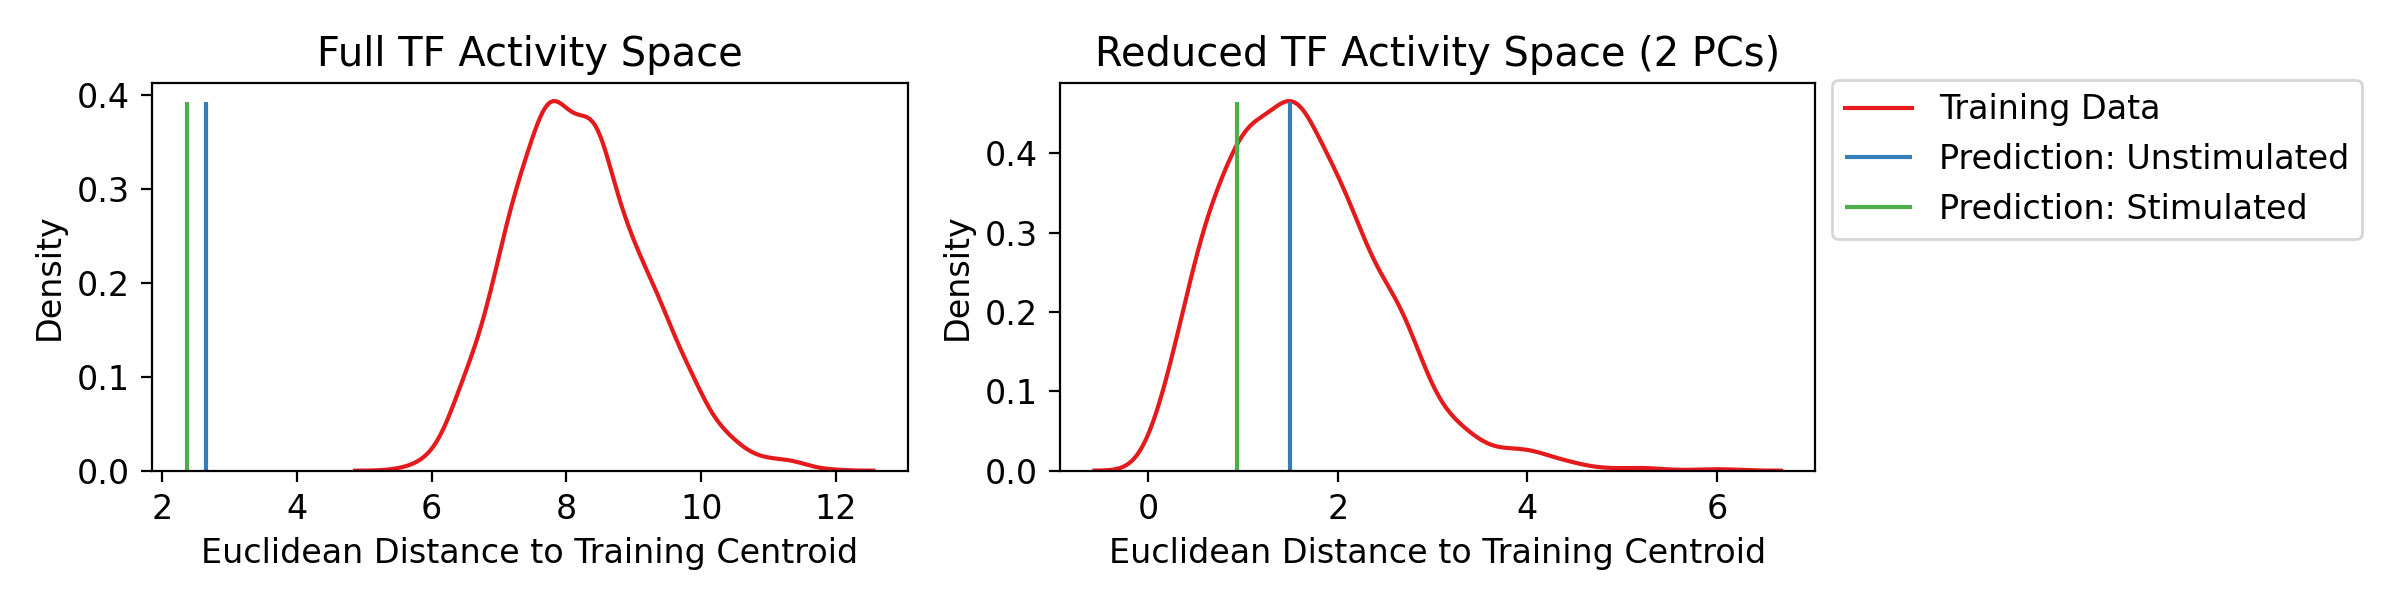

In [163]:
fig, ax = plt.subplots(figsize = (12,3), ncols = 2)

colors = sns.color_palette('Set1')

sns.kdeplot(y_train_eds_full, ax = ax[0], color = colors[0])
# children = plt.gca().get_children()
l0 = ax[0].vlines(np.linalg.norm(y_pred_0 - train_centroids.loc[0,:].values), ymin = 0, ymax = 0.95*ax[0].get_ylim()[1], color = colors[1])
l1 = ax[0].vlines(np.linalg.norm(y_pred_1 - train_centroids.loc[1,:].values), ymin = 0, ymax = 0.95*ax[0].get_ylim()[1], color = colors[2])
ax[0].set_xlabel('Euclidean Distance to Training Centroid')
ax[0].set_title('Full TF Activity Space')

sns.kdeplot(y_train_eds_reduced, ax = ax[1], color = colors[0])
children = plt.gca().get_children()
l0 = ax[1].vlines(np.linalg.norm(pred_pca_centroids[0,:train_pc_rank] - train_pca_centroids[0,:train_pc_rank]), ymin = 0, ymax = 0.95*ax[1].get_ylim()[1], color = colors[1])
l1 = ax[1].vlines(np.linalg.norm(pred_pca_centroids[1,:train_pc_rank] - train_pca_centroids[1,:train_pc_rank]), ymin = 0, ymax = 0.95*ax[1].get_ylim()[1], color = colors[2])
ax[1].set_xlabel('Euclidean Distance to Training Centroid')
ax[1].set_title('Reduced TF Activity Space ({} PCs)'.format(train_pc_rank))

plt.legend([children[0], l0, l1], ['Training Data', 'Prediction: Unstimulated', 'Prediction: Stimulated'], 
          bbox_to_anchor=(1, 1.05))
fig.tight_layout()

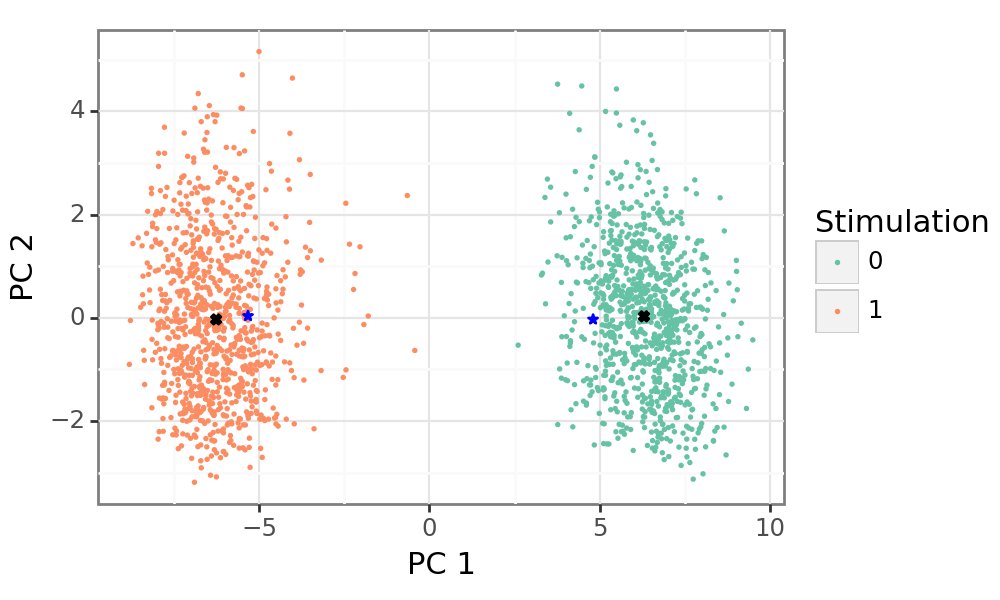

<Figure Size: (500 x 300)>

In [196]:
width, height = 5, 3

tf_adata_train.obs['Stimulation'] = ligand_input.loc[tf_adata_train.obs.index, selected_ligand]

# training data
X_train = tf_adata_train.obsm['X_pca']
X_train = pd.DataFrame(tf_adata_train.obsm['X_pca'][:, :2], index = tf_adata_train.obs.index, 
                         columns = ['PC_' + str(i+1) for i in range(2)])
col_labels = [' '.join(i.split('_')) for i in X_train.columns]
X_train = pd.concat([X_train, tf_adata_train.obs.Stimulation], axis = 1)

# centroids and predicted values
X_centroids = pd.DataFrame(train_pca_centroids[:, :2], index = clf_full.classes_, 
                     columns = ['PC_' + str(i+1) for i in range(2)])
X_pred = pd.DataFrame(pred_pca_centroids[:, :2], index = clf_full.classes_, 
                     columns = ['PC_' + str(i+1) for i in range(2)])

p3 = (
    p9.ggplot() +
    p9.geom_point(X_train, p9.aes(x=X_train.columns[0], y = X_train.columns[1], color = 'Stimulation'), 
                 size = 0.1) +
    p9.scale_color_manual(values=['#66c2a5', '#fc8d62']) +
    p9.geom_point(X_centroids, p9.aes(x=X_train.columns[0], y = X_train.columns[1]), shape = 'X', color = 'black') +
    p9.geom_point(X_pred, p9.aes(x=X_pred.columns[0], y = X_pred.columns[1]), shape = '*', color = 'blue') +
    p9.xlab(col_labels[0]) + p9.ylab(col_labels[1]) + 
    p9.theme_bw() + p9.theme(figure_size=(width, height))  
    
)
p3

Altogether, these results demonstrate that bulk LEMBAS is capturing the average TF activity of a given cluster.


Some nuances:
- In full TF activity space, which the model was trained on, the predictions are very close to the average value for each condition (moreso than an individual data point). In the reduced space, they are slightly off and fall within the distribution of all training data, perhaps due to small discrepancies being amplified by loading values in the PC space. 
- Additionally, they both fall closer to each other in the PC1 direction of highest variance, indicating that they are distinguishing between the two conditions more poorly. 

This is interesting to keep in mind, indicating that those TF's that explain high levels of variance between conditions may be particularly sensitive to error. It may be worth introducing a higher penalty in the loss term for TFs with high loadings in PC1.